In [131]:
import pandas as pd

In [132]:
df=pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [133]:
df.dropna(inplace=True)

In [134]:
df["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '3 Bedroom', '1 RK', '4 BHK',
       '1 BHK', '5 BHK', '11 BHK', '5 Bedroom', '9 BHK', '2 Bedroom',
       '6 BHK', '7 BHK', '6 Bedroom'], dtype=object)

In [135]:
df["bhk"]=df["size"].apply(lambda x : int(x.split(' ')[0]))

In [136]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00,2
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785,5.0,3.0,295.00,4
...,...,...,...,...,...,...,...,...,...,...
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345,2.0,1.0,57.00,3
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00,3
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00,5
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00,2


In [137]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price', 'bhk'],
      dtype='object')

In [138]:
df["total_sqft"].unique()

array(['1056', '2600', '1521', ..., '1919', '2111', '4689'], dtype=object)

In [139]:
def convert_sqft_to_num(x):
    try:  
        if '-' in x:
            nums = x.split('-')
            return (float(nums[0]) + float(nums[1])) / 2
        return float(x)
    except :
        return None

In [140]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_num)

In [141]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170.0,2.0,1.0,38.00,2
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785.0,5.0,3.0,295.00,4
...,...,...,...,...,...,...,...,...,...,...
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345.0,2.0,1.0,57.00,3
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715.0,3.0,3.0,112.00,3
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453.0,4.0,0.0,231.00,5
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141.0,2.0,1.0,60.00,2


In [142]:
df2=df.copy()

In [143]:
df2.location = df2.location.apply(lambda x: x.strip())

In [144]:
location_stat= df2.groupby("location")["location"].agg("count")
location_stat

location
1 Giri Nagar                       1
1st Block Jayanagar                1
1st Block Koramangala              2
1st Phase JP Nagar                14
2nd Block Hrbr Layout              1
                                  ..
Yelahanka New Town                22
Yelenahalli                        3
Yemlur                             3
Yeshwanthpur                      63
Yeshwanthpur Industrial Suburb     1
Name: location, Length: 626, dtype: int64

In [127]:
loaction_stat_grater_10 = location_stat[location_stat < 10]

In [128]:
loaction_stat_grater_10

location
1 Giri Nagar                      1
1st Block Jayanagar               1
1st Block Koramangala             2
2nd Block Hrbr Layout             1
2nd Block Jayanagar               1
                                 ..
Wilson Garden                     3
Yelachenahalli                    8
Yelenahalli                       3
Yemlur                            3
Yeshwanthpur Industrial Suburb    1
Name: location, Length: 472, dtype: int64

In [100]:
df2.location = df2.location.apply(lambda x:"other" if x in loaction_stat_grater_10 else x)

In [101]:
df[df.location=="other"]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
18,Super built-up Area,Ready To Move,other,3 BHK,PeBayle,2770.0,4.0,2.0,290.00,3
42,Super built-up Area,Ready To Move,other,1 BHK,Ceove G,600.0,1.0,0.0,38.00,1
50,Super built-up Area,Ready To Move,other,2 BHK,Bhncyis,1270.0,2.0,1.0,50.00,2
57,Super built-up Area,Ready To Move,other,2 BHK,PeBayle,1500.0,2.0,2.0,185.00,2
61,Super built-up Area,Ready To Move,other,2 BHK,Laavevi,845.0,2.0,1.0,55.00,2
...,...,...,...,...,...,...,...,...,...,...
13276,Super built-up Area,Ready To Move,other,2 BHK,ThhtsV,1000.0,2.0,1.0,49.50,2
13278,Built-up Area,Ready To Move,other,2 BHK,Sariana,1256.0,2.0,1.0,65.00,2
13285,Super built-up Area,Ready To Move,other,2 BHK,OlarkLa,1353.0,2.0,2.0,110.00,2
13292,Super built-up Area,18-Jul,other,3 BHK,Plowsri,1440.0,2.0,2.0,63.93,3


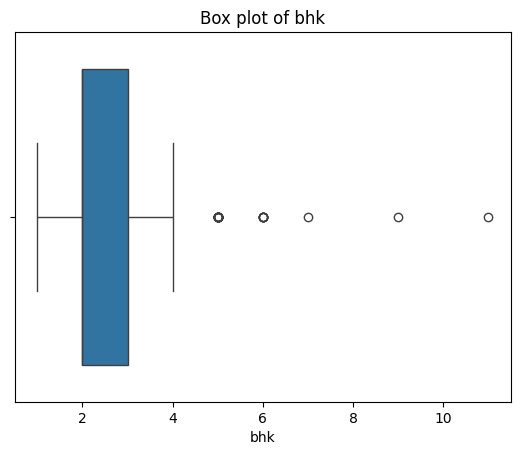

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['bhk'])
plt.title('Box plot of bhk')
plt.show()

In [107]:
Q1 = df['bhk'].quantile(0.25)
Q3 = df['bhk'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataframe to keep only non-outliers
df = df[(df['bhk'] >= lower_bound) & (df['bhk'] <= upper_bound)]

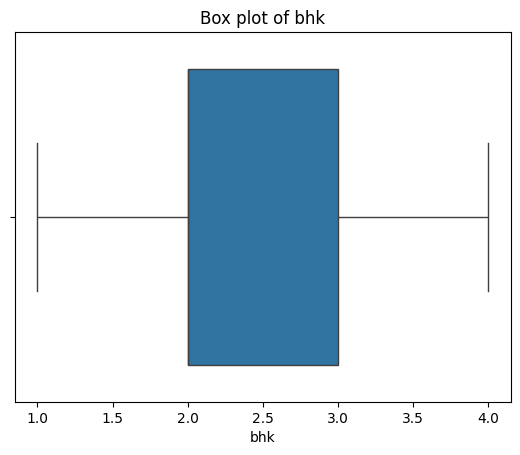

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['bhk'])
plt.title('Box plot of bhk')
plt.show()

In [109]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,3
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170.0,2.0,1.0,38.00,2
11,Plot Area,Ready To Move,Whitefield,4 Bedroom,Prrry M,2785.0,5.0,3.0,295.00,4
...,...,...,...,...,...,...,...,...,...,...
13308,Built-up Area,Ready To Move,Bannerghatta Road,3 BHK,Baanise,1527.0,3.0,1.0,142.00,3
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345.0,2.0,1.0,57.00,3
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715.0,3.0,3.0,112.00,3
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141.0,2.0,1.0,60.00,2


In [110]:
df = df.drop(['availability','society','area_type','balcony'],axis='columns') 
df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
5,Whitefield,2 BHK,1170.0,2.0,38.00,2
11,Whitefield,4 Bedroom,2785.0,5.0,295.00,4


In [113]:
len(df.location.unique())

155